# HNSWlib


### 1. hnswlib (Hierarchical NSW) —— 核心代码 `hnswlib_clerc_runner.cpp`

根据 HNSW 论文第四、五节及运行参数，影响曲线的最核心参数如下：

| 参数类别 | 参数名称 | 对应代码/文档变量 | 对 QPS-Accuracy / MRR / Recall 曲线的影响机理 |
| :--- | :--- | :--- | :--- |
| **运行时 (直接旋钮)** | **`ef_search`** | `argv[9]` (文档设为 100) | **决定性超参数**。增大 `ef_search` 会扩展搜索时的动态候选列表（论文 Algorithm 2 中的 `W`），显著提高召回率和 MRR（因为能找到更优的最近邻），但会导致距离计算次数急剧增加，**QPS 直线下降**。这是绘制权衡曲线最核心的调节变量。 |
| **构建时 (质量天花板)** | **`M`** | `argv[7]` (文档设为 16) | 每层每个节点的最大出度。增大 `M` 使图连接更密集，提高索引的“导航”精度（相同 `ef_search` 下 Recall/MRR 更高），但会增大内存访问开销和贪心路径的度数，**降低 QPS**。论文建议 5~48 之间调节。 |
| **构建时 (质量天花板)** | **`ef_construction`** | `argv[8]` (文档设为 200) | 构建索引时的动态候选列表大小。该值越大，构建的图质量越高（更接近 Delaunay 图），使得在**相同的 `ef_search`** 下获得更高的 Recall/MRR。但它不影响搜索时的 QPS，只影响曲线的饱和上限。 |
| **隐式结构参数** | **`M_max0`** (零层连接数) | 代码中默认使用 `M * 2` | 论文第 4.1 节指出，若设置过小（等于 M），高召回率下性能会严重退化；设为 `2*M` 能保证高 Recall 下的搜索效率。若手动调整该值（需改源码），会显著影响高 Recall 区域的 QPS 曲线形态。 |

> **绘图策略**：固定 `M=16`, `ef_construction=200`，**仅调整 `ef_search`**（如从 10 扫到 500），即可完美绘制出 hnswlib 的三条曲线。

---

### 2. HCNNG —— 文档 `README_clerc_large_single.md`

| 参数类别 | 参数名称 | 对应文档命令 | 对曲线的影响机理 |
| :--- | :--- | :--- | :--- |
| **运行时 (直接旋钮)** | **`max_calc`** | `search` 命令第 6 个参数（文档设为 2000） | **唯一直接影响权衡的运行时参数**。它限制了每查询的向量距离计算次数（搜索预算）。预算越大，贪心路由探索范围越广，Recall/MRR 越高，但 QPS 严格线性下降。 |
| **构建时** | **`target_cluster_size`** | `hcnng` 命令第 2 个参数（文档设为 1000） | 影响树的层级划分。较小的目标簇大小会使树更深，虽然能略微改善搜索初期定位，但在高维数据（1024维）下影响远小于 `max_calc`。 |

> **绘图策略**：固定索引参数，**仅调整 `max_calc`**（如从 100 到 5000）绘制曲线。

---

### 额外影响曲线形态的全局因素（代码中可见）

- **搜索线程数 (`search_threads` / `--nworker` / OpenMP 并行)**：在 `hnswlib_clerc_runner` 和 ELPIS 中，增加线程数会显著**提升 QPS**（吞吐量），但在单查询延迟（latency）上可能略有开销。它不会改变算法理论上的 Accuracy/Recall，但会使 **QPS-Accuracy 曲线整体向上平移**。文档中 hnswlib 刻意设置了 `search_threads=1` 来测纯算法延迟。

### 总结：绘制三条曲线的最简参数集

| 算法 | **需调节的运行时参数 (X轴变量)** | **需固定的结构参数** |
| :--- | :--- | :--- |
| **HNSW (hnswlib)** | **`ef_search`** | `M` (建议16), `ef_construction` (建议200) |
| **HCNNG** | **`max_calc`** (搜索预算) | `target_cluster_size` (建议1000) |
| **ELPIS** | **`--nprobes`** (探测叶数) | `--kb` (16), `--Lb` (200), `--L` (100), `--leaf-size` (100) |


### 📊 核心参数映射表（论文 → 代码）

| 论文中的符号 | 论文含义 | 代码中的变量名 | 命令行位置（你的脚本） | 备注 |
| :--- | :--- | :--- | :--- | :--- |
| **\( K \)** | 最终返回的邻居数量 | `k` | 第 6 个参数（固定 100） | 对应你的 `Recall@100` 中的 100。 |
| **\( M \)** | **每层**中每个节点的最大出度（连接数） | `M` | 第 7 个参数（你设的 16/32/64） | **最重要的索引构建参数**。决定图的基础“稠密”程度。 |
| **\( efConstruction \)** | 构建时动态候选列表的大小 | `ef_construction` | 第 8 个参数（你设的 100/200/400） | 控制构建索引时的“工作量/质量”。值越大，构建越慢，索引越好。 |
| **\( ef \)**（搜索时） | 搜索时动态候选列表的大小 | `ef_search` | 第 9 个参数（你扫描的 10~8000） | **画帕累托曲线的直接开关**。控制查询时的“深度/广度”。 |
| **\( m_l \)** | 层级生成的归一化因子（控制每层保留概率） | **未显式出现** | 代码中未传递 | 在 `hnswlib` 源码中默认公式为 `1.0 / log(M)`，遵循论文建议值。 |
| **\( M_{max} \)** | 非零层的最大连接数（上限） | **内部固定** | 构造函数默认设为 `M` | 由库自动接管，不允许用户命令行调整。 |
| **\( M_{max0} \)** | 第 0 层（最底层）的最大连接数 | **内部固定** | 构造函数默认设为 `2 * M` | 论文建议 `2*M`，库已按此实现（对应论文图 6 的结论）。 |

---

### 🔍 针对你的脚本，特别解释两个“隐形”参数

你在命令行中只传了 `M`、`ef_construction` 和 `ef_search`，但论文里还提到了 `m_l`、`M_max0`。为什么你没传？

1.  **关于 `m_l`（层级概率）**：
    - 论文公式为 \( L = \lfloor -\ln(unif(0,1)) \cdot m_l \rfloor \)。
    - 在你的代码 `hnswlib_clerc_runner` 中，虽然没传这个参数，但 `hnswlib` 库的构造函数内部默认使用了 **`m_l = 1.0 / log(M)`**。
    - **这就是为什么你调大 `M`（比如从 16 调到 64），层数会自动减少（因为 `1/log(64) < 1/log(16)`），这是完全符合论文图 3/4/5 中“自动选择值”逻辑的。**

2.  **关于 `M_max0`（底层连接上限）**：
    - 论文图 6 明确指出 `M_max0 = 2*M` 时性能最佳。
    - `hnswlib` 库的底层实现（`hnswlib.h`）恰好将 `maxM0_` 默认设为 `2 * M`。因此你没有必要传这个参数，库已经帮你做了最优选择。

In [ ]:
# Compile the C++ runner

g++ /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/hnswlib_clerc_runner.cpp \
  -O3 -std=c++14 -fopenmp \
  -o /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/hnswlib_clerc_runner

In [5]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re

def plot_hnsw_combinations(
    base_dir: str,
    M_list=None,
    efc_list=None,
    ef_search_list=None,
    topk=100,
    metric='Recall@100',
    figsize=(14, 6),
    show_labels=False,
    save_fig=True
):
    combo_pattern = re.compile(r'^M(\d+)_efc(\d+)$')
    combo_data = []

    for item in os.listdir(base_dir):
        item_path = os.path.join(base_dir, item)
        if not os.path.isdir(item_path):
            continue
        match = combo_pattern.match(item)
        if not match:
            continue
        M_val = int(match.group(1))
        efc_val = int(match.group(2))

        if M_list is not None and M_val not in M_list:
            continue
        if efc_list is not None and efc_val not in efc_list:
            continue

        csv_path = os.path.join(item_path, "summary.csv")
        if not os.path.isfile(csv_path):
            print(f"警告: 缺失 {csv_path}，跳过")
            continue

        df = pd.read_csv(csv_path)
        df = df[df['K'] == topk]
        if df.empty:
            print(f"警告: {csv_path} 中无 K={topk} 数据，跳过")
            continue
        if ef_search_list is not None:
            df = df[df['ef_search'].isin(ef_search_list)]
            if df.empty:
                continue
        df = df.sort_values("QPS")
        combo_data.append((item, M_val, efc_val, df))

    if not combo_data:
        print("没有符合条件的数据，无法绘图。")
        return

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['font.size'] = 12

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # -------------------- 颜色改进 --------------------
    n_curves = len(combo_data)
    if n_curves <= 10:
        cmap = plt.cm.tab10
    elif n_curves <= 20:
        cmap = plt.cm.tab20
    else:
        # 使用 HSV 或 gist_ncar 提供更多种颜色
        cmap = plt.cm.gist_ncar  # 或 plt.cm.hsv
    colors = [cmap(i / n_curves) for i in range(n_curves)]
    # -------------------------------------------------

    for (combo_name, M_val, efc_val, df), color in zip(combo_data, colors):
        label = f"M={M_val}, efc={efc_val}"
        ax1.plot(df["QPS"], df[metric],
                 marker='o', linestyle='-', linewidth=2, markersize=6,
                 color=color, label=label)
        ax2.plot(df["QPS"], df["MRR@100"],
                 marker='s', linestyle='-', linewidth=2, markersize=6,
                 color=color, label=label)

        if show_labels:
            for _, row in df.iterrows():
                ax1.annotate(str(row['ef_search']),
                             xy=(row["QPS"], row[metric]),
                             xytext=(3, 3), textcoords='offset points',
                             fontsize=8, alpha=0.7)
                ax2.annotate(str(row['ef_search']),
                             xy=(row["QPS"], row["MRR@100"]),
                             xytext=(3, 3), textcoords='offset points',
                             fontsize=8, alpha=0.7)

    ax1.set_xlabel("QPS (queries/sec)", fontsize=14)
    ax1.set_ylabel(metric, fontsize=14)
    ax1.set_title(f"QPS vs {metric}", fontsize=16)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.set_xscale('log')
    ax1.set_xticks([1, 10, 100, 1000])
    ax1.set_xticklabels(['$10^0$', '$10^1$', '$10^2$', '$10^3$'])

    ax2.set_xlabel("QPS (queries/sec)", fontsize=14)
    ax2.set_ylabel("MRR@100", fontsize=14)
    ax2.set_title("QPS vs MRR@100", fontsize=16)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.set_xscale('log')
    ax2.set_xticks([1, 10, 100, 1000])
    ax2.set_xticklabels(['$10^0$', '$10^1$', '$10^2$', '$10^3$'])

    ax1.legend(loc='best', fontsize=10)
    ax2.legend(loc='best', fontsize=10)

    plt.tight_layout()

    if save_fig:
        save_path = os.path.join(base_dir, "combined_curves.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图片已保存至: {save_path}")

    plt.show()

---

## Clerc-large

In [ ]:
# Run hnswlib on the 1000-query subset

/home/ali/SVR-baselines/runs/hnswlib_clerc_runner \
  /data/ali/clerc-large-single/clerc-large-single_base.fvecs \
  /data/ali/baseline-data/clerc-large-single/inputs/query_1000.fvecs \
  /data/ali/baseline-data/clerc-large-single/hnswlib/index.bin \
  /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/clerc-large-single/hnswlib/ans_k100_scored.tsv \
  1000 \
  100 \
  16 \
  200 \
  100 \
  96 \
  1 \
  > /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/clerc-large-single/logs/hnswlib_k100_scored.log 2>&1


Argument meaning:

- `1000`: number of queries to run
- `100`: return top-100 neighbors
- `16`: `M`
- `200`: `ef_construction`
- `100`: `ef_search`
- `96`: build threads
- `1`: search threads

Important:

- this runner is C++ only
- index construction may use multiple threads
- search is intentionally one query at a time with one search thread
- the logged `[Search Time]` excludes result-file writing

In [ ]:
# hnswlib Evaluate Recall@10 and Recall@100

python3 /home/ali/SVR-baselines/runs/eval_recall.py \
  --groundtruth /data/ali/baseline-data/clerc-large-single/inputs/groundtruth_1000.ivecs \
  --results /home/ali/SVR-baselines/runs/clerc-large-single/hnswlib/ans_k100_scored.tsv \
  --k 1

python3 /home/ali/SVR-baselines/runs/eval_recall.py \
  --groundtruth /data/ali/baseline-data/clerc-large-single/inputs/groundtruth_1000.ivecs \
  --results /home/ali/SVR-baselines/runs/clerc-large-single/hnswlib/ans_k100_scored.tsv \
  --k 10

python3 /home/ali/SVR-baselines/runs/eval_recall.py \
  --groundtruth /data/ali/baseline-data/clerc-large-single/inputs/groundtruth_1000.ivecs \
  --results /home/ali/SVR-baselines/runs/clerc-large-single/hnswlib/ans_k100_scored.tsv \
  --k 100

In [ ]:
# BEIR-style evaluation

python3 /home/ali/SVR-baselines/runs/eval_beir_metrics.py \
  --groundtruth /data/ali/baseline-data/clerc-large-single/inputs/groundtruth_1000.ivecs \
  --results /home/ali/SVR-baselines/runs/clerc-large-single/hnswlib/ans_k100_scored.tsv \
  --k-values 1 3 5 10 100 \
  --output-json /home/ali/SVR-baselines/runs/clerc-large-single/hnswlib/beir_metrics_k100_scored.json

In [ ]:
# hnswlib QPS

the logged QPS is already the search-only QPS to use.

## Scidocs

默认 M=16, ef_construction=200

search thread 可调

In [ ]:
cd svr-baselines

bash hnswlib_scidocs.sh

图片已保存至: /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/hnswlib/combined_curves.png


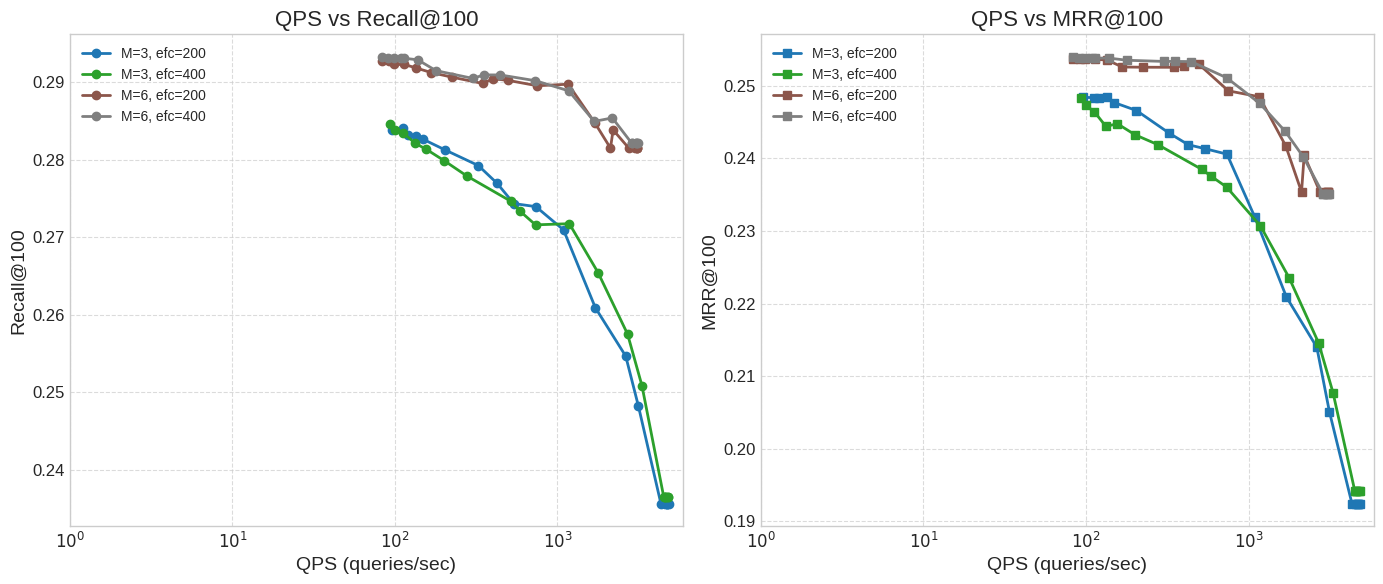

In [10]:
# 绘制所有组合（不过滤）
plot_hnsw_combinations(
    base_dir='/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/hnswlib',
    topk=100,
    metric='Recall@100',
    M_list=[3, 6],
    efc_list=[200, 400],
    show_labels=False
)

# M=3, efc=200

## Fiqa

In [ ]:
cd svr-baselines

bash hnswlib_fiqa.sh

In [15]:
extract_hnsw_metrics(
    base_dir="/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/fiqa-single/hnswlib",
    logs_dir="/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/fiqa-single/logs"
)

汇总结果已保存至: /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/fiqa-single/hnswlib/summary.csv


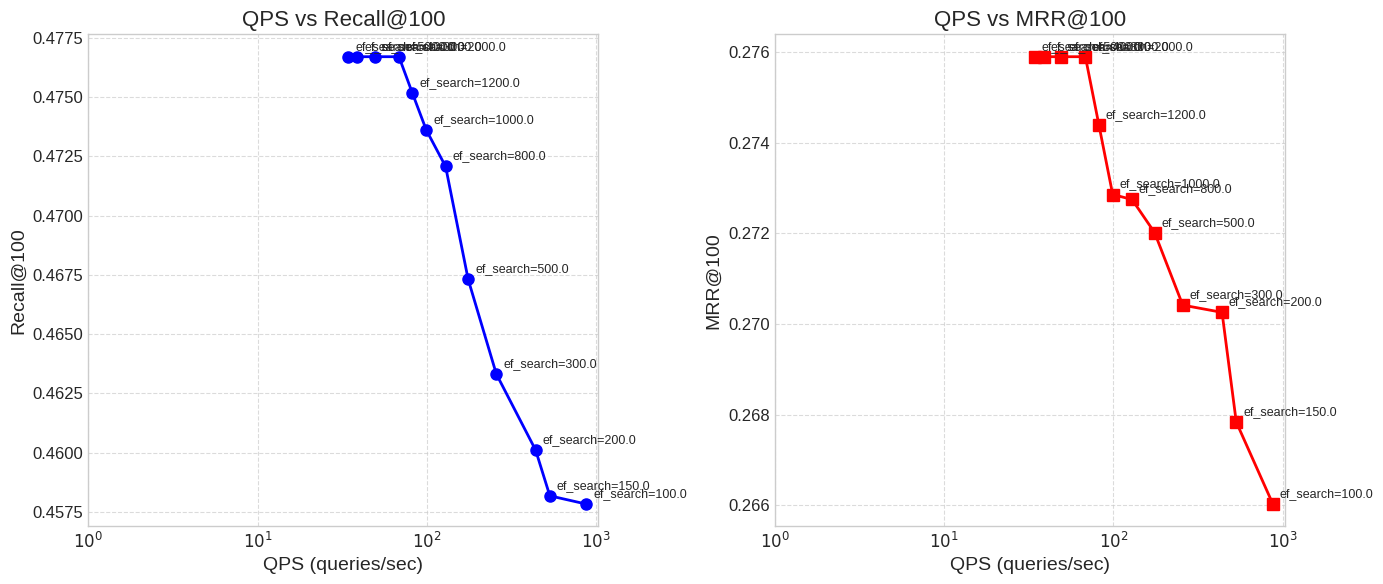

图片已保存为 '/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/fiqa-single/hnswlib/summary.png'


In [16]:
plot_qps_metrics("/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/fiqa-single/hnswlib/summary.csv",
                  topk=100, 
                  ef_search_list=[100, 150, 200, 300, 500, 800, 1000, 1200, 2000, 3000, 4000, 5000])